LIBRARIES

In [ ]:
# libraries
import torch
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

CHECK GPU/CPU

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [48]:
# processed dataset path and training parameters
TRAIN_DIR  = "../dataset/processed/train"
TEST_DIR   = "../dataset/processed/test"
VAL_DIR    = "../dataset/processed/val"
BATCH_SIZE = 64

In [49]:
# convert data into array form
transforms = transforms.Compose([
    # resize the image to 224x224
    transforms.Resize((224, 224)),
    # convert the image to a tensor and normalize the pixel values to [0, 1]
    transforms.ToTensor(),
    # normalize the image with mean and std for each channel (R, G, B)
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# load the dataset using ImageFolder, which expects the directory structure to be:
train_data = datasets.ImageFolder(TRAIN_DIR, transform=transforms)
test_data  = datasets.ImageFolder(TEST_DIR,  transform=transforms)
val_data   = datasets.ImageFolder(VAL_DIR,   transform=transforms)

In [50]:
from torch.utils.data import DataLoader

In [51]:
# create data loaders for batching and shuffling the data
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# check the shape of the data
images, labels = next(iter(train_loader))

# (batch_size, 3, 224, 224)
print(images.shape)

# (batch_size)  
print(labels.shape)   

torch.Size([64, 3, 224, 224])
torch.Size([64])


In [ ]:
import torch.nn as nn
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
num_classes = len(train_data.classes)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# freeze backbone
for param in model.parameters():
    param.requires_grad = False

# replace classifier head
model.fc = nn.Linear(model.fc.in_features, num_classes)

# move to GPU/CPU
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.0001)

epochs = 25

# =====================
# HISTORY TRACKING
# =====================
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # =====================
    # TRAINING PHASE
    # =====================
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total
    train_loss = train_loss / len(train_loader)

    # =====================
    # VALIDATION PHASE
    # =====================
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            # store for report
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)

    # =====================
    # SAVE HISTORY
    # =====================
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # =====================
    # PRINT RESULTS
    # =====================
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )

c:\Users\aril0\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/25 | Train Loss: 0.7761 | Train Acc: 49.14% | Val Loss: 0.7266 | Val Acc: 48.50%
Epoch 2/25 | Train Loss: 0.6556 | Train Acc: 60.86% | Val Loss: 0.6120 | Val Acc: 66.00%
Epoch 3/25 | Train Loss: 0.5712 | Train Acc: 73.24% | Val Loss: 0.5239 | Val Acc: 79.33%
Epoch 4/25 | Train Loss: 0.5015 | Train Acc: 81.43% | Val Loss: 0.4582 | Val Acc: 84.67%
Epoch 5/25 | Train Loss: 0.4472 | Train Acc: 85.95% | Val Loss: 0.4080 | Val Acc: 89.83%
Epoch 6/25 | Train Loss: 0.3994 | Train Acc: 89.38% | Val Loss: 0.3694 | Val Acc: 91.83%
Epoch 7/25 | Train Loss: 0.3634 | Train Acc: 91.19% | Val Loss: 0.3326 | Val Acc: 93.67%
Epoch 8/25 | Train Loss: 0.3329 | Train Acc: 92.14% | Val Loss: 0.3050 | Val Acc: 94.33%
Epoch 9/25 | Train Loss: 0.3034 | Train Acc: 93.57% | Val Loss: 0.2799 | Val Acc: 95.33%
Epoch 10/25 | Train Loss: 0.2881 | Train Acc: 93.33% | Val Loss: 0.2592 | Val Acc: 95.00%
Epoch 11/25 | Train Loss: 0.2700 | Train Acc: 93.95% | Val Loss: 0.2437 | Val Acc: 95.17%
Epoch 12/25 | Train

In [56]:
print(f"Final Train Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Val Accuracy:   {val_accuracies[-1]:.2f}%")

Final Train Accuracy: 97.00%
Final Val Accuracy:   97.33%


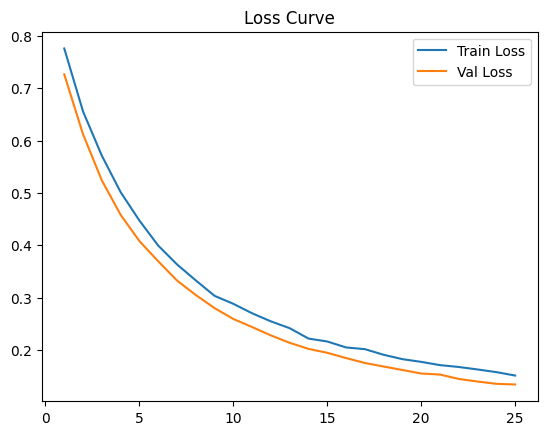

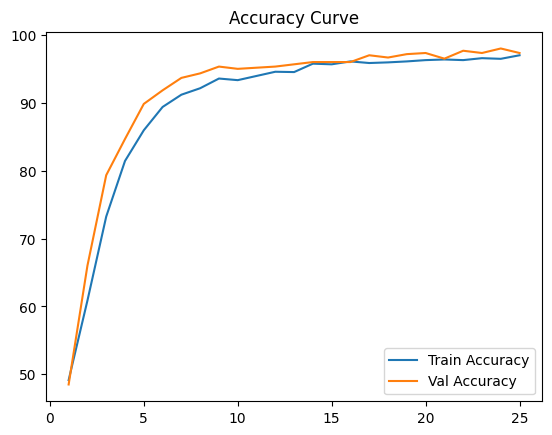

In [57]:
epochs_range = range(1, epochs + 1)

plt.figure()
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, val_accuracies, label="Val Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

In [58]:
# Get the class names from the dataset object
class_names = train_data.classes  # This will be ['label_name_0', 'label_name_1']

# Pass these names to the classification report
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

      masked       0.96      0.99      0.97       300
    unmasked       0.99      0.96      0.97       300

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



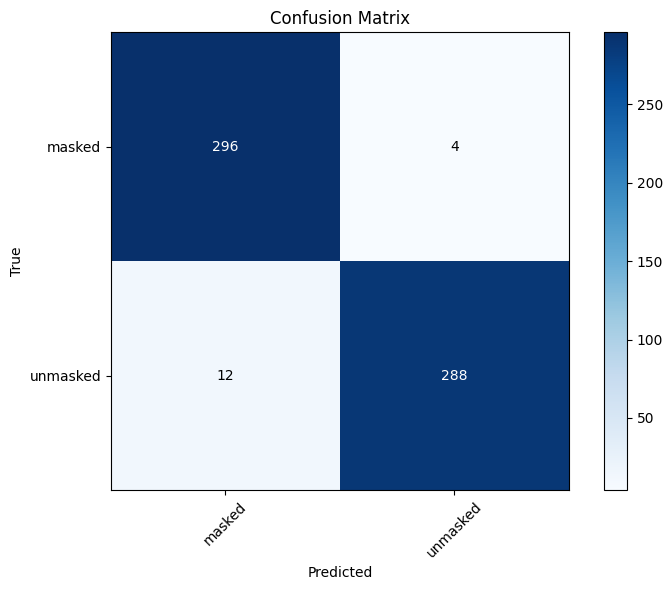

In [59]:
# 1. Get the names from your dataset
class_names = train_data.classes 

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

# 2. Set the tick marks and labels
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# 3. Add text annotations inside the boxes (optional but very helpful)
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [60]:
import os

In [61]:
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)
print(f"Directory ready: {model_dir}")

Directory ready: ../models


In [62]:
model.eval()

# ResNet18 expects (Batch Size, Channels, Height, Width)
# We use a batch size of 1 for the dummy input
dummy_input = torch.randn(1, 3, 224, 224).to(device) 

model_dir = "../models"
onnx_path = os.path.join(model_dir, "drowsiness-detection.onnx")

# Export the model
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    opset_version=18
)

print("ONNX model saved at:", onnx_path)

C:\Users\aril0\AppData\Local\Temp\ipykernel_13372\3340263514.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


c:\Users\aril0\AppData\Local\Programs\Python\Python311\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 41 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model saved at: ../models\drowsiness-detection.onnx


In [63]:
# 1. Save directly in models folder
pth_file_path = os.path.join("../models", "drowsiness-detection.pth")

# 2. Save model weights
torch.save(model.state_dict(), pth_file_path)
print(f"PyTorch model saved at: {pth_file_path}")

PyTorch model saved at: ../models\drowsiness-detection.pth
